In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Imports & Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Fix random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Output directory for saving models and plots
OUT_DIR = Path("outputs_cnn")
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete ✅")

Setup complete ✅


#Configuration
## All hyperparameters and settings are defined here in one place for easy tuning.

In [3]:
# ── File path
FILE_PATH     = "/content/drive/MyDrive/Colab Notebooks/electricity_demand_srilanka_fixed.csv"
TARGET_COL    = "Load Demand (kW)"      # column we want to predict
TIMESTAMP_COL = "Timestamp"             # datetime column

# ── Sequence parameters
LOOKBACK   = 96    # look back 96 steps = 24 hours (15-min intervals)
HORIZON    = 1

# ── Train / validation / test split ratios
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
Test = 0.10

# ── Training hyperparameters
BATCH_SIZE  = 128
MAX_EPOCHS  = 50
LR          = 1e-3    # initial learning rate

#Load Data
## We load the CSV, sort by time, and remove data before 2022 to avoid COVID-period distortions in electricity usage patterns.

In [4]:
# ── Load CSV and parse timestamps
df = pd.read_csv(FILE_PATH, parse_dates=[TIMESTAMP_COL])
df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
df = df.set_index(TIMESTAMP_COL)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df.index[0]}  →  {df.index[-1]}")
df.head(3)

Dataset shape : (189888, 16)
Date range    : 2020-01-01 00:00:00  →  2025-05-31 23:45:00


,Unnamed: 0,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Poya Day
Timestamp,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1202.4797,0
2020-01-01 00:15:00,1,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1213.1439,0
2020-01-01 00:30:00,2,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1215.3267,0


# Feature Engineering
### We create two types of features:

*   **Cyclic time features** — capture daily, weekly, and seasonal patterns using sin/cos encoding
*   **Lag features** — past load values from 24h, 48h, and 1 week ago (safe: no leakage because all lags are ≥ 24h behind the target)



In [5]:
# ── Cyclic encoding for hour, day-of-week, and month
# Using sin/cos so that e.g. hour 23 and hour 0 are "close" to each other
df["sin_hour"]  = np.sin(2 * np.pi * df["Hour of Day"] / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df["Hour of Day"] / 24)
df["sin_dow"]   = np.sin(2 * np.pi * df["Day of Week"] / 7)
df["cos_dow"]   = np.cos(2 * np.pi * df["Day of Week"] / 7)
df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)

# ── Binary weekend flag
df["is_weekend"] = (df["Day of Week"] >= 5).astype(int)

# ── Normalized year (trend signal: 0.0 = 2022, 1.0 = 2025)
df["year_norm"] = (df.index.year - 2022) / 3

# ── Lag features — all shifted ≥ 96 steps (24h) to prevent data leakage
df["load_lag_96"]  = df[TARGET_COL].shift(96)       # 24 hours ago
df["load_lag_192"] = df[TARGET_COL].shift(192)      # 48 hours ago
df["load_lag_672"] = df[TARGET_COL].shift(96 * 7)  # 1 week ago

# ── Rolling statistics anchored at 24h ago (no leakage)
df["load_mean_week"] = df[TARGET_COL].shift(96).rolling(96 * 7).mean()  # 7-day mean
df["load_std_day"]   = df[TARGET_COL].shift(96).rolling(96).std()       # 24h std

# ── Drop rows with NaN (from lag/rolling windows)
df.dropna(inplace=True)
print(f"Rows after dropna: {len(df):,}")

Rows after dropna: 189,121


In [7]:
# ── Define final feature list
FEATURE_COLS = [
    # Weather inputs
    "Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)",
    "Rainfall (mm)", "Solar Irradiance (W/m²)",
    # Time features
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "sin_month", "cos_month", "is_weekend", "year_norm",
    # Calendar events
    "Public Event", "Poya Day",
    # Lag / rolling features
    "load_lag_96", "load_lag_192", "load_lag_672",
    "load_mean_week", "load_std_day",
]

# Keep only columns that actually exist in the dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f"Total features : {len(FEATURE_COLS)}")
print(f"Feature list   : {FEATURE_COLS}")

Total features : 20
Feature list   : ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'is_weekend', 'year_norm', 'Public Event', 'Poya Day', 'load_lag_96', 'load_lag_192', 'load_lag_672', 'load_mean_week', 'load_std_day']


# Leakage Sanity Check
### We check the Pearson correlation of each feature with the target. A correlation > 0.98 would suggest the feature is almost identical to the target — a sign of data leakage.

Safe features have meaningful but not suspiciously perfect correlation.

In [8]:
print(f"{'Feature':<35}  Correlation with Target")
print("-" * 60)

for col in FEATURE_COLS:
    corr = df[col].corr(df[TARGET_COL])
    flag = "  ⚠️  POTENTIAL LEAKAGE" if abs(corr) > 0.98 else ""
    print(f"  {col:<35} {corr:+.4f}{flag}")

Feature                              Correlation with Target
------------------------------------------------------------
  Temperature (°C)                    +0.0132
  Humidity (%)                        +0.0015
  Wind Speed (m/s)                    +0.0016
  Rainfall (mm)                       -0.0024
  Solar Irradiance (W/m²)             -0.0044
  sin_hour                            +0.0636
  cos_hour                            -0.6127
  sin_dow                             +0.1589
  cos_dow                             -0.1787
  sin_month                           +0.2942
  cos_month                           -0.0485
  is_weekend                          -0.2134
  year_norm                           +0.6628
  Public Event                        -0.0642
  Poya Day                            -0.1162
  load_lag_96                         +0.9139
  load_lag_192                        +0.8584
  load_lag_672                        +0.9505
  load_mean_week                      +0.6981
  lo

# Temporal Split & Scaling
### **Important**: We use a **temporal (chronological) split** — never shuffle time-series data!


*   Train: first 70%
*   Validation: next 15%
*   Test: final 15%

Features and target are scaled **separately** with their own StandardScaler.





In [10]:
n       = len(df)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

# ── Chronological split
df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

print(f"Train : {len(df_train):,} samples  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Val   : {len(df_val):,} samples  ({df_val.index[0].date()} → {df_val.index[-1].date()})")
print(f"Test  : {len(df_test):,} samples  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

Train : 151,296 samples  (2020-01-08 → 2024-05-02)
Val   : 18,912 samples  (2024-05-02 → 2024-11-15)
Test  : 18,913 samples  (2024-11-15 → 2025-05-31)


In [11]:
# ── Fit scalers on TRAINING data only, then apply to val/test
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_tr_raw = feat_scaler.fit_transform(df_train[FEATURE_COLS])
y_tr_raw = target_scaler.fit_transform(df_train[[TARGET_COL]])

X_vl_raw = feat_scaler.transform(df_val[FEATURE_COLS])     # transform only!
y_vl_raw = target_scaler.transform(df_val[[TARGET_COL]])

X_te_raw = feat_scaler.transform(df_test[FEATURE_COLS])
y_te_raw = target_scaler.transform(df_test[[TARGET_COL]])

# ── Save scalers for future inference
joblib.dump(feat_scaler,   OUT_DIR / "feat_scaler.pkl")
joblib.dump(target_scaler, OUT_DIR / "target_scaler.pkl")

print("Scalers saved ✅")

Scalers saved ✅


# Build Sliding-Window Sequences
The model needs 3D input: `(samples, timesteps, features)`.

We use a sliding window:
- **X** = window of the past `LOOKBACK` (96) timesteps
- **y** = the single next value (1 step ahead)

In [12]:
def build_sequences(X, y, lookback, horizon=1):
    """
    Convert flat arrays into overlapping windows.
    X shape: (samples, lookback, features)
    y shape: (samples, horizon)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_tr, y_tr = build_sequences(X_tr_raw, y_tr_raw, LOOKBACK, HORIZON)
X_vl, y_vl = build_sequences(X_vl_raw, y_vl_raw, LOOKBACK, HORIZON)
X_te, y_te = build_sequences(X_te_raw, y_te_raw, LOOKBACK, HORIZON)

print(f"Train  X: {X_tr.shape}  y: {y_tr.shape}")
print(f"Val    X: {X_vl.shape}  y: {y_vl.shape}")
print(f"Test   X: {X_te.shape}  y: {y_te.shape}")

# ── Quick check: make sure target is not constant
assert y_tr.std() > 0.01, "❌ Target variance near zero — check sequence building!"
print(f"\nTarget stats — mean: {y_tr.mean():.4f}  std: {y_tr.std():.4f}  ✅")

Train  X: (151200, 96, 20)  y: (151200, 1)
Val    X: (18816, 96, 20)  y: (18816, 1)
Test   X: (18817, 96, 20)  y: (18817, 1)

Target stats — mean: 0.0003  std: 1.0001  ✅


## Build the CNN-Only Model

This is an architecture ablation of the supplied CNN-LSTM model. The two LSTM
layers are removed; the original two-layer causal `Conv1D` block and the
complete Dense/output block are retained unchanged.

`Flatten` is the only required shape-adaptation layer: it converts the 3D CNN
sequence output to the 2D input expected by the unchanged Dense block. It has
no trainable parameters or tunable hyperparameters.

```
Input → Conv1D(64) → Conv1D(32) → Flatten → Dense(64) → Dropout(0.2) → Output(4)
```


In [13]:
n_steps    = LOOKBACK            # configured sequence length (168 timesteps)
n_features = X_tr.shape[2]       # number of input features

# ── Input layer
inp = Input(shape=(n_steps, n_features), name="input")

# ── CNN-only block: unchanged from the CNN-LSTM model
x = Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu")(inp)
x = Conv1D(filters=32, kernel_size=3, padding="causal", activation="relu")(x)

# ── Required shape adaptation from (timesteps, channels) to a feature vector
x = Flatten(name="flatten_sequence")(x)

# ── Output block (unchanged)
x   = Dense(64, activation="relu")(x)
x   = Dropout(0.2)(x)                     # regularization — reduces overfitting
out = Dense(HORIZON)(x)                   # final forecast (4 values)

# ── Compile with the original optimizer, learning rate, loss, and metric
model = Model(inp, out, name="CNN_Forecaster")
model.compile(optimizer=Adam(LR), loss="mae", metrics=["mae"])

model.summary()


Model: "CNN_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_sequence (Flatten)      │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,817 (807.88 KB)

 Trainable params: 206,817 (807.88 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

We use three callbacks:

| Callback | Purpose |
|----------|---------|
| `EarlyStopping` | Stop training when validation loss stops improving |
| `ReduceLROnPlateau` | Halve learning rate when stuck |
| `ModelCheckpoint` | Save the best model weights |

In [17]:
ckpt_path = str(OUT_DIR / "best_model.keras")

callbacks = [
    # Stop if val_loss doesn't improve for 15 epochs; restore best weights
    EarlyStopping(
        monitor="val_loss", patience=15,
        min_delta=1e-4, restore_best_weights=True, verbose=1
    ),
    # Reduce LR by 50% if val_loss plateaus for 8 epochs
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=8, min_lr=1e-5, verbose=1
    ),
    # Save best model to disk
    ModelCheckpoint(
        ckpt_path, monitor="val_loss",
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=False,   # must NOT shuffle time-series data!
    verbose=1,
)

Epoch 1/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1267 - mae: 0.1267 - val_loss: 0.1150 - val_mae: 0.1150 - learning_rate: 0.0010
Epoch 2/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1261 - mae: 0.1261 - val_loss: 0.1097 - val_mae: 0.1097 - learning_rate: 0.0010
Epoch 3/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1266 - mae: 0.1266 - val_loss: 0.1404 - val_mae: 0.1404 - learning_rate: 0.0010
Epoch 4/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1286 - mae: 0.1286 - val_loss: 0.1079 - val_mae: 0.1079 - learning_rate: 0.0010
Epoch 5/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1269 - mae: 0.1269 - val_loss: 0.1529 - val_mae: 0.1529 - learning_rate: 0.0010
Epoch 6/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1275 - mae: 0.1275 - val_loss: 0.1475 - val_mae: 0.1475 - learning_rate: 0.0010
Epoch 7/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1294 - mae: 0.1294 - val_loss: 0.1544 - val_mae: 0.1544 - learning_rate:

## Evaluate the Model

We evaluate on all three splits using four metrics:

| Metric | Meaning |
|--------|---------|
| **MAE** | Mean Absolute Error — average error in kW |
| **RMSE** | Root Mean Squared Error — penalizes large errors more |
| **MAPE** | Mean Absolute Percentage Error — intuitive % error |
| **R²** | Coefficient of determination — 1.0 = perfect fit |

In [18]:
# ── Reload the best saved weights
model.load_weights(ckpt_path)


def evaluate(X, y_scaled, split_name):
    """Predict, inverse-transform, and print metrics for a given split."""
    pred_scaled = model.predict(X, batch_size=BATCH_SIZE, verbose=0)

    # ── Inverse-transform back to original kW scale
    y_true = target_scaler.inverse_transform(y_scaled)
    y_pred = target_scaler.inverse_transform(pred_scaled)

    # ── Warn if predictions are nearly constant (bad sign)
    if y_pred.std() < 1.0:
        print(f"  ⚠️  [{split_name}] Predictions nearly constant — model may not have learned!")

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"  {split_name:6s} → MAE={mae:.2f} kW | RMSE={rmse:.2f} kW | MAPE={mape:.2f}% | R²={r2:.4f}")
    return y_true, y_pred


print("── Evaluation Results ──")
y_tr_true, y_tr_pred = evaluate(X_tr, y_tr, "Train")
y_vl_true, y_vl_pred = evaluate(X_vl, y_vl, "Val")
y_te_true, y_te_pred = evaluate(X_te, y_te, "Test")

── Evaluation Results ──
  Train  → MAE=34.10 kW | RMSE=44.74 kW | MAPE=2.12% | R²=0.9791
  Val    → MAE=23.66 kW | RMSE=33.63 kW | MAPE=1.17% | R²=0.9794
  Test   → MAE=39.46 kW | RMSE=52.37 kW | MAPE=1.78% | R²=0.9181


## Visualize Results

Three plots:
1. **Training curves** — loss over epochs
2. **Predictions vs actuals** — 7-day window on test set
3. **Scatter plot** — predicted vs actual (closer to diagonal = better)

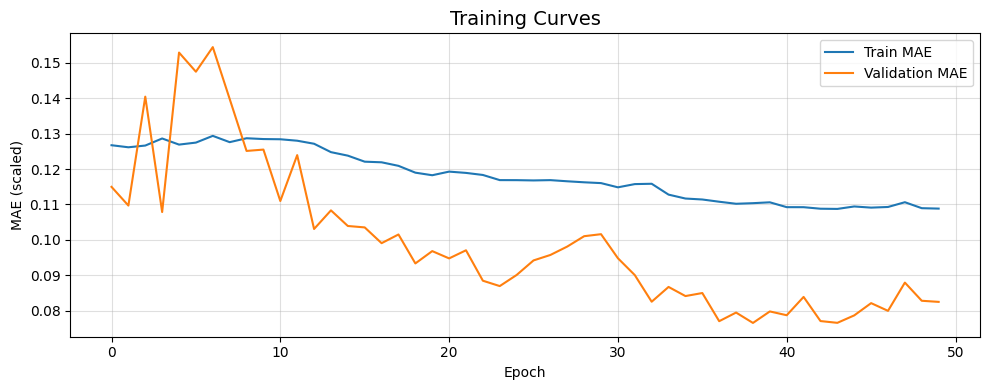

In [19]:
# ── Plot 1: Training & Validation Loss Curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"],     label="Train MAE")
ax.plot(history.history["val_loss"], label="Validation MAE")
ax.set_title("Training Curves", fontsize=14)
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (scaled)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

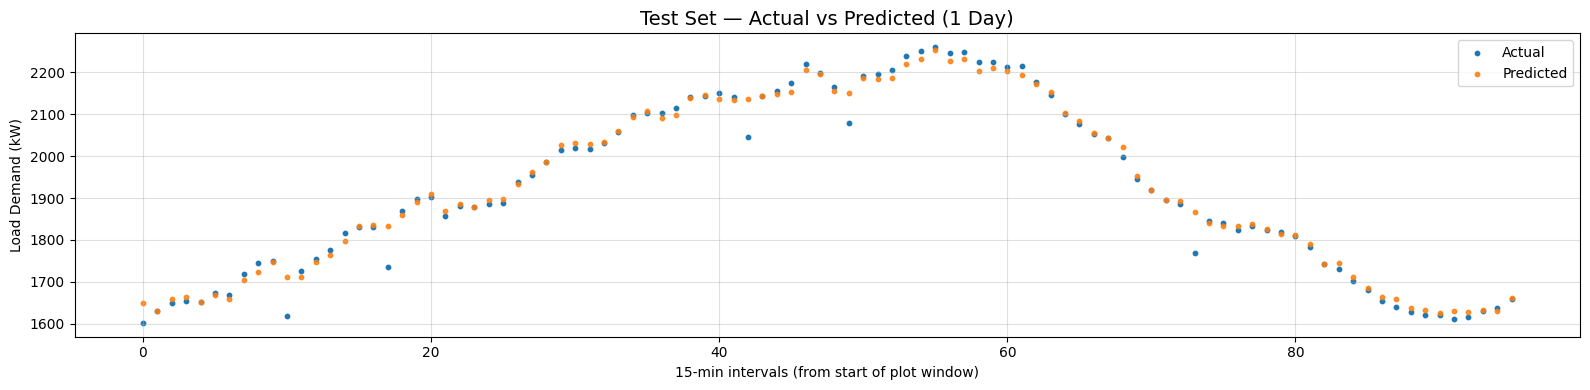

In [20]:
# ── Plot 2: Actual vs Predicted (Scatter) — 1-day window on test set
n_plot = min(4 * 24, len(y_te_true))   # 1 day of 15-min intervals

fig, ax = plt.subplots(figsize=(16, 4))
ax.scatter(range(n_plot), y_te_true[:n_plot, 0], label="Actual", s=10)
ax.scatter(range(n_plot), y_te_pred[:n_plot, 0], label="Predicted", s=10, alpha=0.85)
ax.set_title("Test Set — Actual vs Predicted (1 Day)", fontsize=14)
ax.set_xlabel("15-min intervals (from start of plot window)")
ax.set_ylabel("Load Demand (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "test_predictions_scatter.png", dpi=150)
plt.show()

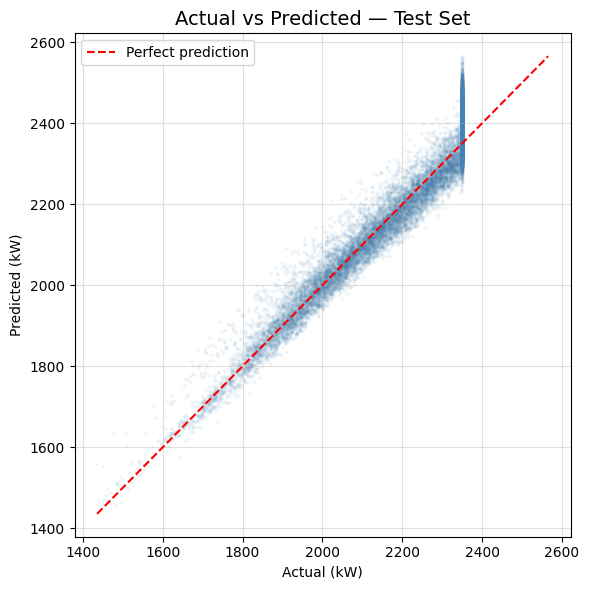

In [21]:
# ── Plot 3: Scatter — Actual vs Predicted
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te_true.flatten(), y_te_pred.flatten(),
           alpha=0.05, s=3, color="steelblue")

# Perfect prediction line
lims = [min(y_te_true.min(), y_te_pred.min()),
        max(y_te_true.max(), y_te_pred.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")

ax.set_title("Actual vs Predicted — Test Set", fontsize=14)
ax.set_xlabel("Actual (kW)")
ax.set_ylabel("Predicted (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "scatter.png", dpi=150)
plt.show()

## Summary

All outputs are saved to the `outputs_cnn/` folder:

| File | Description |
|------|-------------|
| `best_model.keras` | Best trained model checkpoint |
| `feat_scaler.pkl` | Feature scaler (for inference) |
| `target_scaler.pkl` | Target scaler (for inverse-transform) |
| `training_curves.png` | Training and validation loss curves |
| `test_predictions_scatter.png` | One-day test prediction scatter plot |
| `scatter.png` | Full test-set actual-vs-predicted scatter plot |


Predicted and Actual Load Demand for a period in 2022 (from Training Data):

--- First 5 days of 2022 in the training set ---
| Timestamp           | Actual Load Demand (kW)   | Predicted Load Demand (kW)   |
|:--------------------|:--------------------------|:-----------------------------|
| 2022-01-01 00:00:00 | 1368.23                   | 1425.41                      |
| 2022-01-01 00:15:00 | 1345.85                   | 1372.56                      |
| 2022-01-01 00:30:00 | 1329.4                    | 1348.32                      |
| 2022-01-01 00:45:00 | 1359.36                   | 1396.17                      |
| 2022-01-01 01:00:00 | 1401.81                   | 1444.29                      |
| 2022-01-01 01:15:00 | 1402.17                   | 1432.47                      |
| 2022-01-01 01:30:00 | 1423.37                   | 1436.92                      |
| 2022-01-01 01:45:00 | 1441.03                   | 1458.41                      |
| 2022-01-01 02:00:00 | 1448.39             

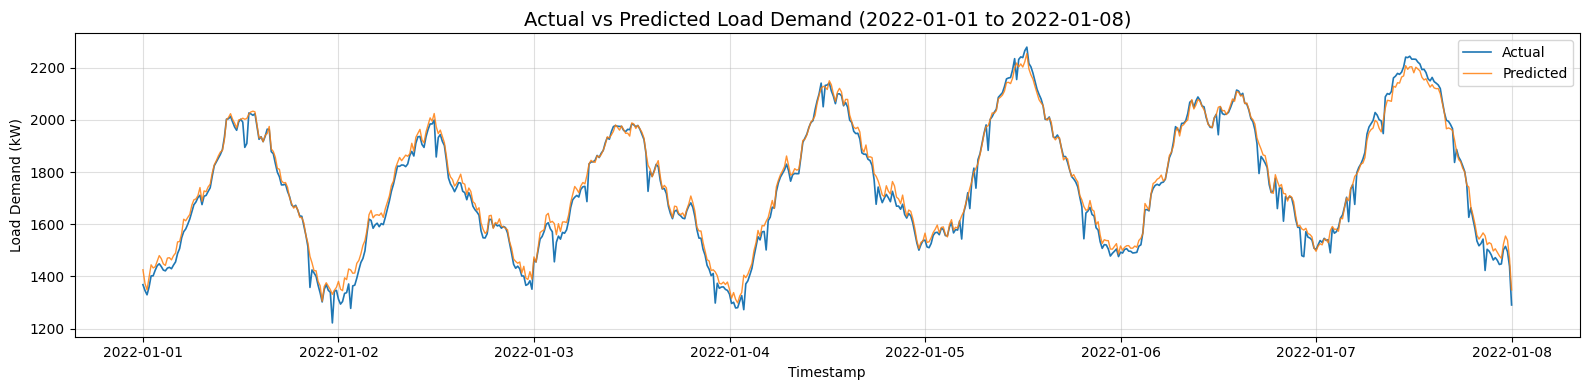

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Reconstruct the original timestamps for the training predictions
# The y_tr_true and y_tr_pred arrays correspond to the target values from
# df_train starting after the LOOKBACK period.
# The index for these predictions should be from df_train starting at LOOKBACK + HORIZON - 1
start_idx_for_pred = LOOKBACK + HORIZON - 1
# The length of y_tr_true is len(df_train) - LOOKBACK - HORIZON + 1
# So the end index in df_train would be start_idx_for_pred + len(y_tr_true) = len(df_train)
train_prediction_timestamps = df_train.index[start_idx_for_pred : start_idx_for_pred + len(y_tr_true)]

# Create a DataFrame to hold actual and predicted values with their timestamps
df_train_predictions_actuals = pd.DataFrame({
    'Actual Load Demand (kW)': y_tr_true[:, 0],
    'Predicted Load Demand (kW)': y_tr_pred[:, 0]
}, index=train_prediction_timestamps)

# Filter for the year 2022
df_2022_period = df_train_predictions_actuals[df_train_predictions_actuals.index.year == 2022]

if not df_2022_period.empty:
    print("Predicted and Actual Load Demand for a period in 2022 (from Training Data):")
    # Display the first few entries (e.g., first 5 days)
    print("\n--- First 5 days of 2022 in the training set ---")
    first_few_days = df_2022_period.head(5 * 24 * 4) # 5 days * 24 hours * 4 (15-min intervals)
    print(first_few_days.to_markdown(numalign="left", stralign="left"))

    # Display the last few entries (e.g., last 5 days)
    print("\n--- Last 5 days of 2022 in the training set ---")
    last_few_days = df_2022_period.tail(5 * 24 * 4)
    print(last_few_days.to_markdown(numalign="left", stralign="left"))

    # Plot a specific period in 2022, for example, the first week of predictions in 2022
    fig, ax = plt.subplots(figsize=(16, 4))
    plot_period_start = df_2022_period.index[0]
    plot_period_end = plot_period_start + pd.Timedelta(days=7)
    plot_data = df_2022_period.loc[plot_period_start : plot_period_end]

    if not plot_data.empty:
        ax.plot(plot_data.index, plot_data['Actual Load Demand (kW)'], label="Actual", lw=1.2)
        ax.plot(plot_data.index, plot_data['Predicted Load Demand (kW)'], label="Predicted", lw=1.0, alpha=0.85)
        ax.set_title(f"Actual vs Predicted Load Demand ({plot_period_start.strftime('%Y-%m-%d')} to {plot_period_end.strftime('%Y-%m-%d')})", fontsize=14)
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Load Demand (kW)")
        ax.legend()
        ax.grid(True, alpha=0.4)
        fig.tight_layout()
        plt.show()
    else:
        print("\nNo sufficient data to plot for the selected period in 2022.")

else:
    print("No predicted or actual data available for the year 2022 in the training set.")

In [23]:
import pandas as pd
import numpy as np
import time

# Measure inference time
start = time.perf_counter()
pred_scaled = model.predict(X_te, batch_size=BATCH_SIZE, verbose=1)
inference_seconds = time.perf_counter() - start

pred_scaled = np.asarray(pred_scaled).reshape(-1, 1)
y_test_scaled = np.asarray(y_te).reshape(-1, 1)

# Convert scaled values back to kW
predicted_kw = target_scaler.inverse_transform(pred_scaled).ravel()
actual_kw = target_scaler.inverse_transform(y_test_scaled).ravel()

# Replace test_timestamps with the timestamp variable used by your notebook
test_timestamps = df_test.index[LOOKBACK + HORIZON -1 :].to_series() # Correctly get timestamps for the test set predictions

assert len(test_timestamps) == len(actual_kw) == len(predicted_kw)
assert len(actual_kw) == len(y_te), f"Unexpected test size: {len(actual_kw)}"

predictions_df = pd.DataFrame({
    "timestamp": test_timestamps,
    "actual": actual_kw,
    "predicted": predicted_kw
})

predictions_df.to_csv("cnn_lstm_predictions_run1.csv", index=False)

print(predictions_df.head())
print("Rows:", len(predictions_df))
print("Inference seconds:", inference_seconds)

148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
                              timestamp       actual    predicted
Timestamp                                                        
2024-11-16 23:45:00 2024-11-16 23:45:00  1602.075439  1649.188721
2024-11-17 00:00:00 2024-11-17 00:00:00  1630.239624  1630.083740
2024-11-17 00:15:00 2024-11-17 00:15:00  1648.674316  1659.349365
2024-11-17 00:30:00 2024-11-17 00:30:00  1654.963501  1663.215454
2024-11-17 00:45:00 2024-11-17 00:45:00  1653.098267  1653.064331
Rows: 18817
Inference seconds: 1.341708707999942
